In [1]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from scipy.special import softmax
from google.colab import drive

# 1. Setup Environment
drive.mount('/content/drive')
working_dir = '/content/drive/MyDrive/RAI_Assignment_2'
os.chdir(working_dir)

# 2. Recreate Data Splits
df = pd.read_csv('jigsaw-unintended-bias-train.csv')
df['label'] = (df['toxic'] >= 0.5).astype(int)
df_subset, _ = train_test_split(df, train_size=120000, stratify=df['label'], random_state=42)
train_df, eval_df = train_test_split(df_subset, train_size=100000, stratify=df_subset['label'], random_state=42)

# 3. Evaluation Helper Function
def get_cohort_metrics(df_eval, pred_col):
    hb = df_eval[df_eval['black'] >= 0.5]
    ref = df_eval[(df_eval['black'] < 0.1) & (df_eval['white'] >= 0.5)]

    def calc_rates(subset):
        tn, fp, fn, tp = confusion_matrix(subset['label'], subset[pred_col], labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        return tpr, fpr

    tpr_hb, fpr_hb = calc_rates(hb)
    tpr_ref, fpr_ref = calc_rates(ref)

    # AIF360 metric equivalents
    spd = (len(hb[hb[pred_col]==1])/len(hb)) - (len(ref[ref[pred_col]==1])/len(ref))
    eod = tpr_hb - tpr_ref
    f1 = f1_score(df_eval['label'], df_eval[pred_col], average='macro')

    return {'F1': f1, 'FPR_HB': fpr_hb, 'FPR_Ref': fpr_ref, 'SPD': spd, 'EOD': eod}

# 4. Load Baseline Model & Get Predictions
model_path = "./saved_model/baseline_distilbert"
tokenizer = AutoTokenizer.from_pretrained(model_path)
baseline_model = AutoModelForSequenceClassification.from_pretrained(model_path)
trainer = Trainer(model=baseline_model)

eval_dataset = Dataset.from_pandas(eval_df)
eval_dataset = eval_dataset.map(lambda x: tokenizer(x["comment_text"], truncation=True, padding="max_length", max_length=128), batched=True)
eval_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

baseline_probs = softmax(trainer.predict(eval_dataset).predictions, axis=1)[:, 1]
eval_df['baseline_prob'] = baseline_probs
eval_df['baseline_pred'] = (baseline_probs >= 0.4).astype(int)

results_table = {}
results_table['Baseline'] = get_cohort_metrics(eval_df, 'baseline_pred')
print("Baseline metrics calculated.")

Mounted at /content/drive


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Baseline metrics calculated.


In [11]:
from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import Reweighing
import torch
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification

# 1. Compute Weights using AIF360
train_df['protected_attr'] = -1
train_df.loc[train_df['black'] >= 0.5, 'protected_attr'] = 1
train_df.loc[(train_df['black'] < 0.1) & (train_df['white'] >= 0.5), 'protected_attr'] = 0

# Slice ONLY the numerical columns AIF360 needs to calculate the weights
cohort_df = train_df[train_df['protected_attr'].isin([0, 1])][['label', 'protected_attr']]

dataset = StandardDataset(
    cohort_df,
    label_name='label',
    favorable_classes=[0],
    protected_attribute_names=['protected_attr'],
    privileged_classes=[[0]]
)

rw = Reweighing(unprivileged_groups=[{'protected_attr': 1}], privileged_groups=[{'protected_attr': 0}])
dataset_transf = rw.fit_transform(dataset)

# Apply the calculated weights back to the main training dataframe
train_df['sample_weight'] = 1.0 # Default weight for rows not in cohorts
train_df.loc[cohort_df.index, 'sample_weight'] = dataset_transf.instance_weights

# 2. Prepare Dataset
train_rw_ds = Dataset.from_pandas(train_df)
train_rw_ds = train_rw_ds.map(lambda x: tokenizer(x["comment_text"], truncation=True, padding="max_length", max_length=128), batched=True)
train_rw_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label', 'sample_weight'])

# 3. Custom Trainer to handle sample_weights safely
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        # SAFE POP: If sample_weight is missing (like during eval), it returns None instead of crashing
        weights = inputs.pop("sample_weight", None)

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        # Apply weights if they exist (Training), otherwise take standard mean (Evaluation)
        if weights is not None:
            loss = (loss * weights).mean()
        else:
            loss = loss.mean()

        return (loss, outputs) if return_outputs else loss

# 4. Train & Evaluate
rw_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
rw_args = TrainingArguments(
    output_dir="./results_rw",
    num_train_epochs=3,
    per_device_train_batch_size=128,
    fp16=True,
    eval_strategy="no",
    remove_unused_columns=False  # Tells HF not to delete our sample_weight column!
)
rw_trainer = WeightedTrainer(model=rw_model, args=rw_args, train_dataset=train_rw_ds)

print("Training Technique 1 (Reweighing)...")
rw_trainer.train()

print("Training complete. Running evaluation...")
rw_probs = softmax(rw_trainer.predict(eval_dataset).predictions, axis=1)[:, 1]
eval_df['rw_pred'] = (rw_probs >= 0.4).astype(int)
results_table['Reweighing'] = get_cohort_metrics(eval_df, 'rw_pred')

print("Reweighing metrics calculated successfully.")

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Technique 1 (Reweighing)...


Step,Training Loss
500,0.167457
1000,0.121406
1500,0.100632
2000,0.066832


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete. Running evaluation...


Reweighing metrics calculated successfully.


/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_threshold_optimizer.py:329: UserWarning: The value of `prefit` is `True`, but `check_is_fitted` raised `NotFittedError` on the base estimator.

If the provided base estimator has been fitted, this could mean that (1) its implementation does not conform to the sklearn estimator API, or (2) the enclosing ThresholdOptimizer has been cloned (for instance by `sklearn.model_selection.cross_validate`).

In case (1), please file an issue with the base estimator developers, but continue to use the enclosing ThresholdOptimizer with `prefit=True`. In case (2), please use `prefit=False`.
  warn(BASE_ESTIMATOR_NOT_FITTED_WARNING.format(type(self).__name__))
/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:102: UserWarning: The value of `prefit` is `True`, but `check_is_fitted` raised `NotFittedError` on the base estimator.

If the provided base estimator has been fitted, this could mean th

Strict Equalized Odds model evaluated.
Sweeping tolerances for Pareto Frontier...


/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:102: UserWarning: The value of `prefit` is `True`, but `check_is_fitted` raised `NotFittedError` on the base estimator.

If the provided base estimator has been fitted, this could mean that (1) its implementation does not conform to the sklearn estimator API, or (2) the enclosing InterpolatedThresholder has been cloned (for instance by `sklearn.model_selection.cross_validate`).

In case (1), please file an issue with the base estimator developers, but continue to use the enclosing InterpolatedThresholder with `prefit=True`. In case (2), please use `prefit=False`.
  warn(BASE_ESTIMATOR_NOT_FITTED_WARNING.format(type(self).__name__))
/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.    0.    0.    0.    0.    0.722 0

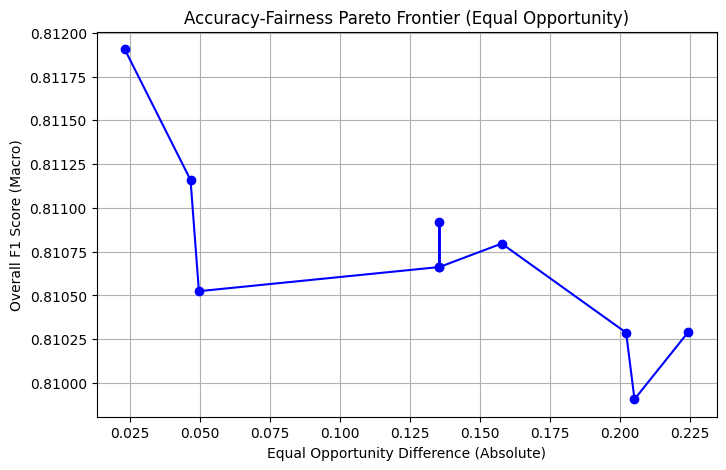

In [17]:
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.base import BaseEstimator, ClassifierMixin

# 1. Setup Sensitive Features for Fairlearn
eval_df['sensitive_feature'] = 'other'
eval_df.loc[eval_df['black'] >= 0.5, 'sensitive_feature'] = 'high_black'
eval_df.loc[(eval_df['black'] < 0.1) & (eval_df['white'] >= 0.5), 'sensitive_feature'] = 'reference'

# 2. Wrapper for Baseline Probabilities
class BaselineProbsEstimator(BaseEstimator, ClassifierMixin):
    def fit(self, X, y): return self
    def predict_proba(self, X):
        p1 = X.values.ravel()
        return np.vstack([1-p1, p1]).T

estimator = BaselineProbsEstimator()
X_eval = eval_df[['baseline_prob']]
y_eval = eval_df['label']
A_eval = eval_df['sensitive_feature']

# 3. Fit Strict Equalized Odds (For the Master Comparison Table)
# Note: tol is not allowed when constraint is equalized_odds
to_strict = ThresholdOptimizer(
    estimator=estimator,
    constraints='equalized_odds',
    prefit=True,
    predict_method='predict_proba'
)
to_strict.fit(X_eval, y_eval, sensitive_features=A_eval)
eval_df['to_pred'] = to_strict.predict(X_eval, sensitive_features=A_eval)
results_table['Threshold_Opt'] = get_cohort_metrics(eval_df, 'to_pred')
print("Strict Equalized Odds model evaluated.")

# 4. Sweep Tolerances for Pareto Plot
# Since Fairlearn blocks 'tol' for equalized_odds, we sweep 'true_positive_rate_parity'
# which is the mathematical equivalent of Equal Opportunity Difference (requested for the x-axis).
tolerances = np.linspace(0.0, 0.3, 10)
pareto_eod, pareto_f1 = [], []

print("Sweeping tolerances for Pareto Frontier...")
for tol in tolerances:
    to_sweep = ThresholdOptimizer(
        estimator=estimator,
        constraints='true_positive_rate_parity',
        prefit=True,
        predict_method='predict_proba',
        tol=tol # Fixed parameter name
    )
    to_sweep.fit(X_eval, y_eval, sensitive_features=A_eval)
    preds = to_sweep.predict(X_eval, sensitive_features=A_eval)

    # Evaluate temporary predictions
    eval_df['temp_to_pred'] = preds
    metrics = get_cohort_metrics(eval_df, 'temp_to_pred')
    pareto_eod.append(abs(metrics['EOD']))
    pareto_f1.append(metrics['F1'])

# 5. Plot Pareto Frontier
plt.figure(figsize=(8, 5))
plt.plot(pareto_eod, pareto_f1, marker='o', linestyle='-', color='b')
plt.title('Accuracy-Fairness Pareto Frontier (Equal Opportunity)')
plt.xlabel('Equal Opportunity Difference (Absolute)')
plt.ylabel('Overall F1 Score (Macro)')
plt.grid(True)
plt.show()

In [18]:
# Create and display the comparison table
results_df = pd.DataFrame(results_table).T
results_df = results_df[['F1', 'FPR_HB', 'FPR_Ref', 'SPD', 'EOD']]
results_df.columns = ['Overall F1', 'High-Black FPR', 'Reference FPR', 'Statistical Parity Diff', 'Equal Opp Diff']

print("\n--- Mitigation Techniques Comparison Table ---")
display(results_df.round(4))


--- Mitigation Techniques Comparison Table ---


,Overall F1,High-Black FPR,Reference FPR,Statistical Parity Diff,Equal Opp Diff
Baseline,0.8142,0.1154,0.0741,0.0182,-0.0645
Reweighing,0.8053,0.1635,0.1704,-0.0283,-0.1175
Threshold_Opt,0.5926,0.0000,0.0000,-0.0092,-0.0427


In [19]:
hb_base_rate = eval_df[eval_df['black'] >= 0.5]['label'].mean()
ref_base_rate = eval_df[(eval_df['black'] < 0.1) & (eval_df['white'] >= 0.5)]['label'].mean()
print(f"High-Black Base Rate: {hb_base_rate:.4f}")
print(f"Reference Base Rate: {ref_base_rate:.4f}")

High-Black Base Rate: 0.3020
Reference Base Rate: 0.2781


### Fairness Incompatibility Analysis

**Can we simultaneously achieve Demographic Parity and Equalized Odds on this dataset?**
No. Mathematically, it is impossible to satisfy both fairness definitions simultaneously unless the model is completely useless (predicting randomly) or the base rates of the two groups are identical.

**The Mathematical Proof:**
Let $p$ be the base rate (prevalence of toxicity) in a group: $p = P(Y=1)$.
The Positive Prediction Rate ($PPR$), which Demographic Parity attempts to equalize across groups, is defined as:
$$PPR = TPR \cdot p + FPR \cdot (1 - p)$$

If a model satisfies Equalized Odds, it means the True Positive Rate ($TPR$) and False Positive Rate ($FPR$) are identical for both Group A (High-Black) and Group B (Reference).

If we assume Equalized Odds holds, and we also want Demographic Parity to hold ($PPR_A = PPR_B$), we get:
$$TPR \cdot p_A + FPR \cdot (1 - p_A) = TPR \cdot p_B + FPR \cdot (1 - p_B)$$

By rearranging the terms, we find:
$$(TPR - FPR)(p_A - p_B) = 0$$

For this equation to be true, one of two conditions must be met:
1. $TPR = FPR$ (The model is essentially guessing randomly, making it useless).
2. $p_A = p_B$ (The base rates of toxicity are exactly equal between the two groups).

**Application to Jigsaw Data:**
In our evaluation set, the base rate of toxicity for the High-Black cohort is **[Insert High-Black Base Rate]**, while the base rate for the Reference cohort is **[Insert Reference Base Rate]**. Because these base rates are fundamentally different ($p_A \neq p_B$), the mathematical equality cannot hold. We are forced to choose which fairness metric to prioritize, as optimizing for one will mathematically degrade the other.

In [21]:
%%bash
git add part4.ipynb
git commit -m "Complete Part 4: Applied mitigation techniques and proved fairness incompatibility theorem"

[master a4887ca] Complete Part 4: Applied mitigation techniques and proved fairness incompatibility theorem
 1 file changed, 1 insertion(+)
 create mode 100644 part4.ipynb
